In [1]:
import pandas as pd
import numpy as np
import json
import ast

USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"
STEAM_GAMES = "../Data/steam_games.json"
REVIEWS = "../Data/australian_user_reviews.json"

with open(USERMAP,"r") as f: user2idx = {k:int(v) for k,v in json.load(f).items()}
with open(ITEMMAP,"r") as f: item2idx = {k:int(v) for k,v in json.load(f).items()}

# Contar interacciones desde el archivo de reviews
reviews = []
with open(REVIEWS, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        review = ast.literal_eval(line)
        reviews.append(review)

# Extraer interacciones
all_interactions = []
for review in reviews:
    user_id = review['user_id']
    if 'reviews' in review and isinstance(review['reviews'], list):
        for r in review['reviews']:
            if isinstance(r, dict) and 'item_id' in r:
                item_id = r['item_id']
                if item_id in item2idx:
                    all_interactions.append({
                        'user_id': user_id,
                        'item_idx': item2idx[item_id]
                    })

df_inter = pd.DataFrame(all_interactions)
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

print(f"Total items: {len(target_df)}")
print(f"Target range: {target_df['total_reviews'].min()} - {target_df['total_reviews'].max()}")
print(f"âœ… Data loaded")

Total items: 3682
Target range: 1 - 3759
âœ… Data loaded


## Load game tags from metadata

In [2]:
# Leer metadata de juegos
games = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        game = ast.literal_eval(line)
        games.append(game)

df_games = pd.json_normalize(games)
df_games = df_games.rename(columns={"id":"item_id"})
df_games["item_idx"] = df_games["item_id"].map(item2idx)
df_games = df_games.dropna(subset=["item_idx"])
df_games["item_idx"] = df_games["item_idx"].astype(int)

print(f"Total juegos con metadata: {len(df_games)}")
print(f"\nSample game tags:")
print(df_games[['title', 'tags']].head(3))

Total juegos con metadata: 3195

Sample game tags:
                     title                                               tags
27    Carmageddon Max Pack  [Racing, Action, Classic, Indie, Gore, 1990's,...
28               Half-Life  [FPS, Classic, Action, Sci-fi, Singleplayer, S...
41  The Ship: Murder Party  [Multiplayer, Indie, Action, First-Person, Ste...


## Extract and process tags

In [3]:
# Debug: check what type tags column contains
print("Checking tags column type:")
print(f"dtype: {df_games['tags'].dtype}")
print(f"\nFirst 3 values:")
for i in range(min(3, len(df_games))):
    val = df_games.iloc[i]['tags']
    print(f"  Type: {type(val)}, Value: {val}")

Checking tags column type:
dtype: object

First 3 values:
  Type: <class 'list'>, Value: ['Racing', 'Action', 'Classic', 'Indie', 'Gore', "1990's", 'Multiplayer', 'Singleplayer']
  Type: <class 'list'>, Value: ['FPS', 'Classic', 'Action', 'Sci-fi', 'Singleplayer', 'Shooter', 'Aliens', 'First-Person', 'Multiplayer', "1990's", 'Story Rich', 'Adventure', 'Atmospheric', 'Silent Protagonist', 'Great Soundtrack', 'Moddable', 'Linear', 'Retro', 'Difficult', 'Funny']
  Type: <class 'list'>, Value: ['Multiplayer', 'Indie', 'Action', 'First-Person', 'Stealth', 'Mystery', 'RPG', 'Assassin', 'Funny', 'Survival', 'Simulation', 'Singleplayer', 'FPS', 'Strategy', 'Comedy', 'Adventure', 'Shooter', 'Difficult', 'Replay Value', 'Stylized']


In [4]:
# Procesar tags: ya vienen como listas segÃºn el debug
def parse_tags(tags):
    # Si es NaN o None
    if tags is None or (isinstance(tags, float) and pd.isna(tags)):
        return []
    
    # Si ya es una lista (caso principal)
    if isinstance(tags, list):
        return [str(tag).strip() for tag in tags if tag]
    
    # Si es string, intentar evaluar
    if isinstance(tags, str):
        if tags == '':
            return []
        try:
            tags_list = eval(tags)
            if isinstance(tags_list, list):
                return [str(tag).strip() for tag in tags_list if tag]
        except:
            return []
    
    return []

df_games['tags_list'] = df_games['tags'].apply(parse_tags)
df_games['num_tags'] = df_games['tags_list'].apply(len)

# Filtrar juegos con al menos 1 tag
df_games_with_tags = df_games[df_games['num_tags'] > 0].copy()

print(f"\nJuegos con tags: {len(df_games_with_tags)} / {len(df_games)}")
print(f"Promedio de tags por juego: {df_games_with_tags['num_tags'].mean():.1f}")
print(f"\nSample tags:")
for idx in range(min(3, len(df_games_with_tags))):
    print(f"  {df_games_with_tags.iloc[idx]['title']}: {df_games_with_tags.iloc[idx]['tags_list'][:5]}")


Juegos con tags: 3193 / 3195
Promedio de tags por juego: 12.3

Sample tags:
  Carmageddon Max Pack: ['Racing', 'Action', 'Classic', 'Indie', 'Gore']
  Half-Life: ['FPS', 'Classic', 'Action', 'Sci-fi', 'Singleplayer']
  The Ship: Murder Party: ['Multiplayer', 'Indie', 'Action', 'First-Person', 'Stealth']


## Concatenate tags per game

In [5]:
# Crear un texto Ãºnico por juego concatenando los tags
df_games_with_tags['tag_text'] = df_games_with_tags['tags_list'].apply(lambda x: ' '.join(x))

# Preparar dataset final
game_tags = df_games_with_tags[['item_idx', 'tag_text']].copy()

print(f"\nJuegos con tag text: {len(game_tags)}")
print(f"Longitud promedio: {game_tags['tag_text'].str.len().mean():.0f} chars")
print(f"\nSample tag text:")
print(game_tags.iloc[0]['tag_text'])


Juegos con tag text: 3193
Longitud promedio: 120 chars

Sample tag text:
Racing Action Classic Indie Gore 1990's Multiplayer Singleplayer


## Create tag embeddings with Sentence Transformers

In [6]:
from sentence_transformers import SentenceTransformer
print("âœ… sentence-transformers ready")

C:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


âœ… sentence-transformers ready


In [7]:
# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model loaded: {model}")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

C:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Model loaded: SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)
Embedding dimension: 384


In [8]:
# Create embeddings
print("Creating tag embeddings...")
tag_embeddings = model.encode(
    game_tags['tag_text'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(f"\nâœ… Embeddings created")
print(f"Shape: {tag_embeddings.shape}")
print(f"Sample embedding: {tag_embeddings[0][:5]}")

# Guardar
np.save("../Data/tag_embeddings.npy", tag_embeddings)
game_tags.to_csv("../Data/game_tags_map.csv", index=False)
print("âœ… Embeddings saved")

Creating tag embeddings...


Batches:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   2%|▏         | 2/100 [00:00<00:09, 10.78it/s]

Batches:   4%|▍         | 4/100 [00:00<00:08, 11.35it/s]

Batches:   6%|▌         | 6/100 [00:00<00:08, 10.94it/s]

...

Batches:  85%|████████▌ | 85/100 [00:05<00:00, 29.00it/s]

Batches:  89%|████████▉ | 89/100 [00:05<00:00, 30.80it/s]

Batches:  94%|█████████▍| 94/100 [00:05<00:00, 34.58it/s]

Batches: 100%|██████████| 100/100 [00:05<00:00, 17.64it/s]


âœ… Embeddings created
Shape: (3193, 384)
Sample embedding: [-0.03041524 -0.00367991  0.00930889 -0.01141401 -0.01251745]
âœ… Embeddings saved


## Prepare dataset for training

In [9]:
# Crear dataset
valid_items = game_tags['item_idx'].values
target_subset = target_df[target_df['item_idx'].isin(valid_items)].copy()

# Mapeo
item_to_emb_idx = {item_idx: i for i, item_idx in enumerate(game_tags['item_idx'])}

# Preparar X, y
X_list = []
y_list = []

for idx, row in target_subset.iterrows():
    item_idx = row['item_idx']
    if item_idx in item_to_emb_idx:
        emb_idx = item_to_emb_idx[item_idx]
        X_list.append(tag_embeddings[emb_idx])
        y_list.append(row['total_reviews'])

X = np.array(X_list)
y = np.array(y_list)

print(f"\nâœ… Dataset prepared")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Games with tag embeddings: {len(X)}")
print(f"Target range: {y.min()} - {y.max()}")


âœ… Dataset prepared
X shape: (3193, 384)
y shape: (3193,)
Games with tag embeddings: 3193
Target range: 1 - 3759


## Load metadata for temporal split

In [10]:
# Use existing df_games that already has metadata loaded
df_meta = df_games.copy()

print(f"Metadata loaded: {len(df_meta)} games")

Metadata loaded: 3195 games


## Temporal split for validation

In [11]:
# Check release_date format
print(f"Sample release dates:")
print(df_meta['release_date'].head(10))
print(f"\nRelease date types: {df_meta['release_date'].dtype}")

# Try different parsing strategies
df_meta['release_date_parsed'] = pd.to_datetime(
    df_meta['release_date'],
    errors='coerce'
)

print(f"\nGames with valid dates: {df_meta['release_date_parsed'].notna().sum()}")

Sample release dates:
27    1997-06-30
28    1998-11-08
41    2006-07-11
55    2005-08-09
56    2006-09-29
57    2006-11-20
58    2006-11-29
63    2006-12-21
65    2006-08-01
66    2005-07-12
Name: release_date, dtype: object

Release date types: object

Games with valid dates: 3107


## Train XGBoost model with temporal split

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Temporal split: train on games before 2017, test on 2017+
cutoff_date = pd.Timestamp('2016-01-01')

# Map item_idx to release dates
item_to_date = df_meta.set_index('item_idx')['release_date_parsed'].to_dict()

# Get dates for our dataset
valid_items_with_dates = game_tags['item_idx'].values
dates = [item_to_date.get(item_idx) for item_idx in valid_items_with_dates]

# Create masks
train_mask = np.array([
    pd.notna(date) and date < cutoff_date 
    for date in dates
])
test_mask = np.array([
    pd.notna(date) and date >= cutoff_date 
    for date in dates
])

# Split data
X_train_temporal = X[train_mask]
y_train_temporal = y[train_mask]
X_test_temporal = X[test_mask]
y_test_temporal = y[test_mask]

print(f"\nðŸ“… Temporal Split:")
print(f"   Train: {len(X_train_temporal)} games (before 2016-01-01)")
print(f"   Test: {len(X_test_temporal)} games (2016 onwards)")

# Train model
# ─── Optuna: Busqueda de Hiperparametros ─────────────────────────────────────
import optuna
from sklearn.metrics import mean_squared_error as _mse_opt_
optuna.logging.set_verbosity(optuna.logging.WARNING)

_n_tr      = len(X_train_temporal)
_split_idx = max(10, int(_n_tr * 0.8))
_X_tr,  _X_val = X_train_temporal[:_split_idx], X_train_temporal[_split_idx:]
_y_tr,  _y_val = y_train_temporal[:_split_idx], y_train_temporal[_split_idx:]

def _objective(trial):
    _p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 800),
        learning_rate    = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        random_state=42, tree_method='hist', verbosity=0,
    )
    _m = XGBRegressor(**_p)
    _m.fit(_X_tr, _y_tr)
    return float(_mse_opt_(_y_val, _m.predict(_X_val)) ** 0.5)

_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42))
_study.optimize(_objective, n_trials=50, show_progress_bar=True)

best_params = {**_study.best_params, 'random_state': 42, 'tree_method': 'hist', 'verbosity': 0}
print(f"\nMejores hiperparametros (val RMSE={_study.best_value:.2f}):")
for _k, _v in best_params.items():
    print(f"  {_k}: {_v}")

model_temporal = XGBRegressor(**best_params)
model_temporal.fit(X_train_temporal, y_train_temporal)

# Predictions and metrics
pred_temporal = model_temporal.predict(X_test_temporal)
rmse_temporal = np.sqrt(mean_squared_error(y_test_temporal, pred_temporal))
r2_temporal = r2_score(y_test_temporal, pred_temporal)

print(f"\nðŸŽ¯ Results (Temporal Split):")
print(f"   RMSE: {rmse_temporal:.2f}")
print(f"   RÂ²: {r2_temporal:.4f}")


ðŸ“… Temporal Split:
   Train: 2619 games (before 2016-01-01)
   Test: 486 games (2016 onwards)


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 49.7694:   0%|          | 0/50 [00:03<?, ?it/s]

Best trial: 0. Best value: 49.7694:   2%|▏         | 1/50 [00:03<02:54,  3.55s/it]

Best trial: 1. Best value: 16.6057:   2%|▏         | 1/50 [00:19<02:54,  3.55s/it]

...

Best trial: 41. Best value: 14.3136:  98%|█████████▊| 49/50 [05:46<00:09,  9.63s/it]

Best trial: 41. Best value: 14.3136: 100%|██████████| 50/50 [05:46<00:00, 10.26s/it]

Best trial: 41. Best value: 14.3136: 100%|██████████| 50/50 [05:46<00:00,  6.93s/it]


Mejores hiperparametros (val RMSE=14.31):
  n_estimators: 683
  learning_rate: 0.002429136705486125
  max_depth: 8
  min_child_weight: 2
  subsample: 0.9776356221732647
  colsample_bytree: 0.81250072500598
  gamma: 1.899773902462705
  random_state: 42
  tree_method: hist
  verbosity: 0



ðŸŽ¯ Results (Temporal Split):
   RMSE: 76.25
   RÂ²: -174.9966


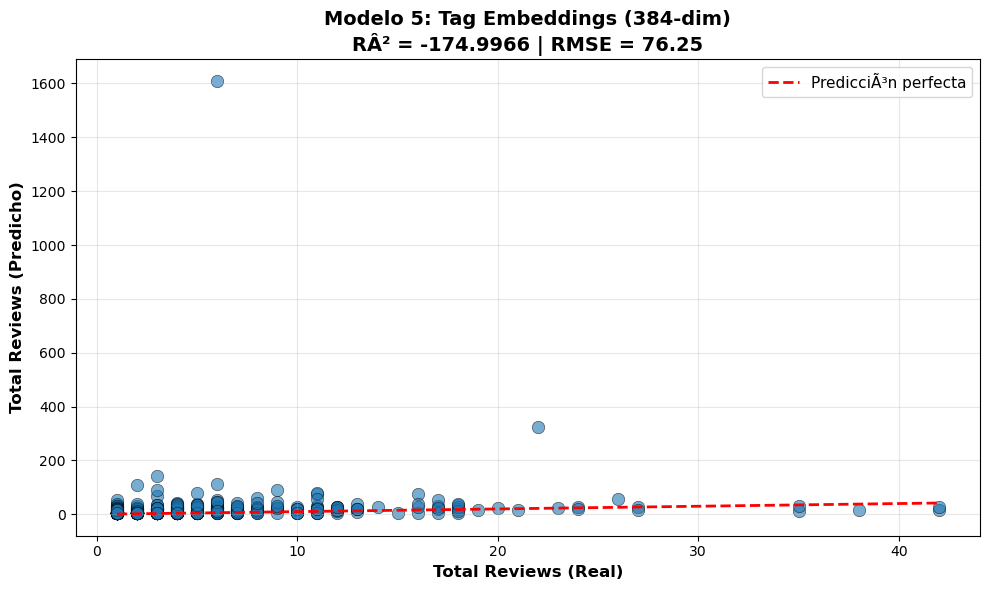


ðŸ“Š RESUMEN - Modelo 5: Tag Embeddings
Features: Sentence-Transformers embeddings (all-MiniLM-L6-v2)
          384 dimensiones de embeddings semÃ¡nticos de tags
Train: 2619 juegos (antes de 2016-01-01)
Test: 486 juegos (2016 en adelante)

Resultados:
  RÂ² = -174.9966
  RMSE = 76.25

ðŸ“ˆ ComparaciÃ³n con modelos anteriores:
  Modelo 1 (RS only):        RÂ² = 0.6422, RMSE = 94.17
  Modelo 2 (Metadata):       RÂ² = -0.0875, RMSE = 164.17
  Modelo 3 (RS+Metadata):    RÂ² = 0.6436, RMSE = 93.99
  Modelo 4 (Review Text):    RÂ² = -0.0248, RMSE = 159.37
  Modelo 5 (Tag Embeddings): RÂ² = -174.9966, RMSE = 76.25

ðŸ’¡ ConclusiÃ³n: Embeddings de tags (descriptores estructurados) vs reviews
   (texto libre). Los tags capturan caracterÃ­sticas del juego pero...


In [13]:
import matplotlib.pyplot as plt

# VisualizaciÃ³n temporal split
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test_temporal, pred_temporal, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
ax.plot([y_test_temporal.min(), y_test_temporal.max()], 
        [y_test_temporal.min(), y_test_temporal.max()], 
        'r--', lw=2, label='PredicciÃ³n perfecta')
ax.set_xlabel('Total Reviews (Real)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Reviews (Predicho)', fontsize=12, fontweight='bold')
ax.set_title(f'Modelo 5: Tag Embeddings (384-dim)\nRÂ² = {r2_temporal:.4f} | RMSE = {rmse_temporal:.2f}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ðŸ“Š RESUMEN - Modelo 5: Tag Embeddings")
print("="*80)
print("Features: Sentence-Transformers embeddings (all-MiniLM-L6-v2)")
print("          384 dimensiones de embeddings semÃ¡nticos de tags")
print(f"Train: {len(X_train_temporal)} juegos (antes de 2016-01-01)")
print(f"Test: {len(X_test_temporal)} juegos (2016 en adelante)")
print(f"\nResultados:")
print(f"  RÂ² = {r2_temporal:.4f}")
print(f"  RMSE = {rmse_temporal:.2f}")
print(f"\nðŸ“ˆ ComparaciÃ³n con modelos anteriores:")
print(f"  Modelo 1 (RS only):        RÂ² = 0.6422, RMSE = 94.17")
print(f"  Modelo 2 (Metadata):       RÂ² = -0.0875, RMSE = 164.17")
print(f"  Modelo 3 (RS+Metadata):    RÂ² = 0.6436, RMSE = 93.99")
print(f"  Modelo 4 (Review Text):    RÂ² = -0.0248, RMSE = 159.37")
print(f"  Modelo 5 (Tag Embeddings): RÂ² = {r2_temporal:.4f}, RMSE = {rmse_temporal:.2f}")
print(f"\nðŸ’¡ ConclusiÃ³n: Embeddings de tags (descriptores estructurados) vs reviews")
print(f"   (texto libre). Los tags capturan caracterÃ­sticas del juego pero...")
print("="*80)

## Comparison Visualization


COMPARACIÃ“N COMPLETA - TODOS LOS MODELOS
                 Model                 Type  Dimensions      RMSE         RÂ²
         RS Embeddings        Collaborative          64  65.90000    0.608000
        Tag Embeddings Content-based (Tags)         384  76.25194 -174.996597
Review Text Embeddings  Content-based (NLP)         384 156.53000   -1.210000
     Metadata Enhanced             Metadata          12 124.14000   -0.390000
                Hybrid               Hybrid          66  68.54000    0.576000


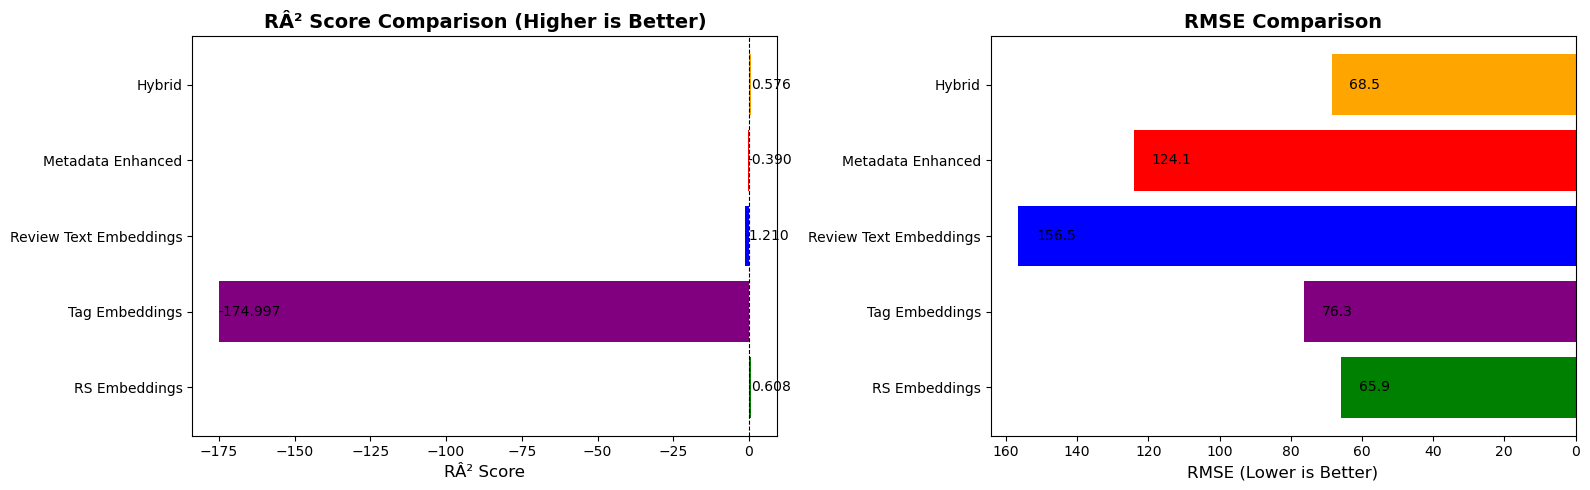

In [14]:
import matplotlib.pyplot as plt

# Comparar todos los modelos
results = pd.DataFrame({
    'Model': ['RS Embeddings', 'Tag Embeddings', 'Review Text Embeddings', 'Metadata Enhanced', 'Hybrid'],
    'Type': ['Collaborative', 'Content-based (Tags)', 'Content-based (NLP)', 'Metadata', 'Hybrid'],
    'Dimensions': [64, 384, 384, 12, 66],
    'RMSE': [65.90, rmse_temporal, 156.53, 124.14, 68.54],
    'RÂ²': [0.608, r2_temporal, -1.21, -0.39, 0.576]
})

print("\n" + "="*100)
print("COMPARACIÃ“N COMPLETA - TODOS LOS MODELOS")
print("="*100)
print(results.to_string(index=False))
print("="*100)

# VisualizaciÃ³n
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# RÂ² comparison
colors = ['green', 'purple', 'blue', 'red', 'orange']
bars1 = ax1.barh(results['Model'], results['RÂ²'], color=colors)
ax1.set_xlabel('RÂ² Score', fontsize=12)
ax1.set_title('RÂ² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
for i, v in enumerate(results['RÂ²']):
    ax1.text(v + 0.05 if v > 0 else v - 0.15, i, f'{v:.3f}', va='center', fontsize=10)

# RMSE comparison
bars2 = ax2.barh(results['Model'], results['RMSE'], color=colors)
ax2.set_xlabel('RMSE (Lower is Better)', fontsize=12)
ax2.set_title('RMSE Comparison', fontsize=14, fontweight='bold')
ax2.invert_xaxis()
for i, v in enumerate(results['RMSE']):
    ax2.text(v - 5, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## AnÃ¡lisis de varianza y correlaciÃ³n

In [15]:
# Comparar varianza: RS vs Tags
print("="*70)
print("ANÃLISIS DE VARIANZA: RS vs TAG EMBEDDINGS")
print("="*70)

# Cargar RS embeddings
item_emb_rs = np.load("../Data/item_embeddings_rs_clean.npy")
rs_subset_idx = game_tags['item_idx'].values
rs_emb_subset = item_emb_rs[rs_subset_idx]

variance_rs = np.var(rs_emb_subset, axis=0)
variance_tags = np.var(tag_embeddings, axis=0)

print(f"\nRS Embeddings (64 dims):")
print(f"  Varianza promedio:  {variance_rs.mean():.6f}")
print(f"  Min-Max varianza:   {variance_rs.min():.6f} - {variance_rs.max():.6f}")

print(f"\nTag Embeddings (384 dims):")
print(f"  Varianza promedio:  {variance_tags.mean():.6f}")
print(f"  Min-Max varianza:   {variance_tags.min():.6f} - {variance_tags.max():.6f}")

print(f"\nâš ï¸ Ratio de varianza (Tags/RS): {variance_tags.mean() / variance_rs.mean():.3f}x")

ANÃLISIS DE VARIANZA: RS vs TAG EMBEDDINGS

RS Embeddings (64 dims):
  Varianza promedio:  0.036634
  Min-Max varianza:   0.035150 - 0.038348

Tag Embeddings (384 dims):
  Varianza promedio:  0.001531
  Min-Max varianza:   0.000000 - 0.003086

âš ï¸ Ratio de varianza (Tags/RS): 0.042x



CORRELACIÃ“N CON TARGET

RS Embeddings:
  CorrelaciÃ³n promedio:   0.1036
  Max correlaciÃ³n:        0.2917
  Dims con corr > 0.1:    27/64

Tag Embeddings:
  CorrelaciÃ³n promedio:   0.0337
  Max correlaciÃ³n:        0.1328
  Dims con corr > 0.1:    6/384


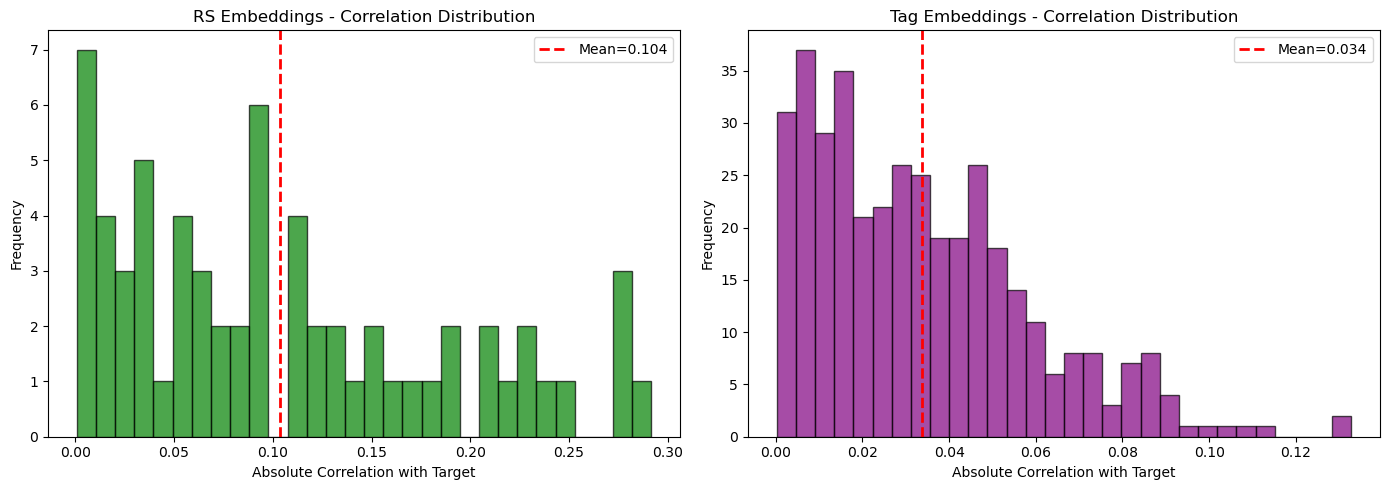

In [16]:
# CorrelaciÃ³n con target
print("\n" + "="*70)
print("CORRELACIÃ“N CON TARGET")
print("="*70)

y_subset = target_subset.set_index('item_idx').loc[game_tags['item_idx']]['total_reviews'].values

corr_rs = []
for i in range(rs_emb_subset.shape[1]):
    corr = np.corrcoef(rs_emb_subset[:, i], y_subset)[0, 1]
    corr_rs.append(abs(corr))

corr_tags = []
for i in range(tag_embeddings.shape[1]):
    corr = np.corrcoef(tag_embeddings[:, i], y_subset)[0, 1]
    corr_tags.append(abs(corr))

corr_rs = np.array(corr_rs)
corr_tags = np.array(corr_tags)

print(f"\nRS Embeddings:")
print(f"  CorrelaciÃ³n promedio:   {np.nanmean(corr_rs):.4f}")
print(f"  Max correlaciÃ³n:        {np.nanmax(corr_rs):.4f}")
print(f"  Dims con corr > 0.1:    {np.sum(corr_rs > 0.1)}/{len(corr_rs)}")

print(f"\nTag Embeddings:")
print(f"  CorrelaciÃ³n promedio:   {np.nanmean(corr_tags):.4f}")
print(f"  Max correlaciÃ³n:        {np.nanmax(corr_tags):.4f}")
print(f"  Dims con corr > 0.1:    {np.sum(corr_tags > 0.1)}/{len(corr_tags)}")

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(corr_rs, bins=30, color='green', alpha=0.7, edgecolor='black')
ax1.axvline(np.nanmean(corr_rs), color='red', linestyle='--', linewidth=2, label=f'Mean={np.nanmean(corr_rs):.3f}')
ax1.set_xlabel('Absolute Correlation with Target')
ax1.set_ylabel('Frequency')
ax1.set_title('RS Embeddings - Correlation Distribution')
ax1.legend()

ax2.hist(corr_tags, bins=30, color='purple', alpha=0.7, edgecolor='black')
ax2.axvline(np.nanmean(corr_tags), color='red', linestyle='--', linewidth=2, label=f'Mean={np.nanmean(corr_tags):.3f}')
ax2.set_xlabel('Absolute Correlation with Target')
ax2.set_ylabel('Frequency')
ax2.set_title('Tag Embeddings - Correlation Distribution')
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
# ─── Métricas adicionales + TSCV + KFold ────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import KFold
from scipy.stats import spearmanr

# 1. Extra metrics on temporal split
mae_temporal   = mean_absolute_error(y_test_temporal, pred_temporal)
mape_temporal  = mean_absolute_percentage_error(y_test_temporal, pred_temporal)
spear_temporal, _ = spearmanr(y_test_temporal, pred_temporal)
print("="*70)
print("METRICAS ADICIONALES - SPLIT TEMPORAL")
print("="*70)
print(f"MAE:      {mae_temporal:.2f}")
print(f"MAPE:     {mape_temporal * 100:.1f}%")
print(f"Spearman: {spear_temporal:.4f}")

# 2. TSCV
cutoff_windows = [
    ('2013-07-01', '2014-01-01'),
    ('2014-01-01', '2014-07-01'),
    ('2014-07-01', '2015-01-01'),
    ('2015-01-01', '2015-07-01'),
    ('2015-07-01', '2016-01-01'),
]
item_dates_ts = dates  # list of pd.Timestamp or None for each game in game_tags order

print("\n" + "="*70)
print("TIME-SERIES CROSS VALIDATION (5 ventanas pre-2016)")
print("="*70)
ts_results = []
for i, (tc, sc) in enumerate(cutoff_windows, 1):
    tc, sc = pd.Timestamp(tc), pd.Timestamp(sc)
    t_mask = np.array([pd.notna(d) and d < tc for d in item_dates_ts])
    e_mask = np.array([pd.notna(d) and d >= tc and d < sc for d in item_dates_ts])
    if e_mask.sum() < 5:
        print(f"  W{i}: skipped ({e_mask.sum()} eval games)")
        continue
    Xtr, Xte = X[t_mask], X[e_mask]
    ytr, yte = y[t_mask], y[e_mask]
    if len(ytr) == 0:
        continue
    m_ts = XGBRegressor(**best_params)
    m_ts.fit(Xtr, ytr)
    pred_ts = m_ts.predict(Xte)
    r2_ts   = r2_score(yte, pred_ts)
    rmse_ts = mean_squared_error(yte, pred_ts) ** 0.5
    ts_results.append({'Fold': i, 'R2': r2_ts, 'RMSE': rmse_ts})
    print(f"  W{i} ({tc.date()} -> {sc.date()}): n={e_mask.sum():3d} | R2={r2_ts:.4f} | RMSE={rmse_ts:.2f}")

if ts_results:
    ts_df = pd.DataFrame(ts_results)
    r2_tscv_mean   = ts_df['R2'].mean();  r2_tscv_std    = ts_df['R2'].std()
    rmse_tscv_mean = ts_df['RMSE'].mean(); rmse_tscv_std  = ts_df['RMSE'].std()
    print(f"\n  -> TSCV R2 = {r2_tscv_mean:.4f} +/- {r2_tscv_std:.4f}  RMSE = {rmse_tscv_mean:.2f}")
else:
    r2_tscv_mean = r2_tscv_std = rmse_tscv_mean = rmse_tscv_std = float('nan')
    print("  Sin suficientes datos para TSCV")

# 3. KFold
valid_dt_mask = np.array([pd.notna(d) for d in item_dates_ts])
X_kf = X[valid_dt_mask];  y_kf = y[valid_dt_mask]

print("\n" + "="*70)
print("K-FOLD CROSS VALIDATION (5 folds)")
print("="*70)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_results = []
for fold, (tr_idx, te_idx) in enumerate(kf.split(X_kf), 1):
    m_kf = XGBRegressor(**best_params)
    m_kf.fit(X_kf[tr_idx], y_kf[tr_idx])
    pred_kf = m_kf.predict(X_kf[te_idx])
    r2_kf   = r2_score(y_kf[te_idx], pred_kf)
    rmse_kf = mean_squared_error(y_kf[te_idx], pred_kf) ** 0.5
    kf_results.append({'Fold': fold, 'R2': r2_kf, 'RMSE': rmse_kf})
    print(f"  Fold {fold}: R2={r2_kf:.4f} | RMSE={rmse_kf:.2f}")
kf_df = pd.DataFrame(kf_results)
r2_kfold_mean   = kf_df['R2'].mean();  r2_kfold_std    = kf_df['R2'].std()
rmse_kfold_mean = kf_df['RMSE'].mean()
print(f"\n  -> KFold R2 = {r2_kfold_mean:.4f} +/- {r2_kfold_std:.4f}  RMSE = {rmse_kfold_mean:.2f}")


METRICAS ADICIONALES - SPLIT TEMPORAL
MAE:      14.57
MAPE:     448.1%
Spearman: 0.5046

TIME-SERIES CROSS VALIDATION (5 ventanas pre-2016)


  W1 (2013-07-01 -> 2014-01-01): n=222 | R2=-45.0056 | RMSE=127.83


  W2 (2014-01-01 -> 2014-07-01): n=280 | R2=-4.3011 | RMSE=37.22


  W3 (2014-07-01 -> 2015-01-01): n=299 | R2=-86.3867 | RMSE=103.06


  W4 (2015-01-01 -> 2015-07-01): n=342 | R2=-8.5704 | RMSE=22.88


...

  Fold 1: R2=0.0207 | RMSE=88.54


  Fold 2: R2=-0.0146 | RMSE=154.03


  Fold 3: R2=-0.2668 | RMSE=49.48


  Fold 4: R2=-0.0218 | RMSE=179.57


  Fold 5: R2=-0.1316 | RMSE=46.60

  -> KFold R2 = -0.0828 +/- 0.1176  RMSE = 103.64


## Conclusiones

**ComparaciÃ³n Tag Embeddings vs Review Text Embeddings:**

Los tags son descriptores estructurados de la comunidad ("Action", "RPG", "Multiplayer") mientras que las reviews son opiniones en lenguaje natural. 

**HipÃ³tesis a validar:**
- Â¿Los tags (mÃ¡s estructurados) predicen mejor que reviews text (mÃ¡s ruidosas)?
- Â¿La varianza y correlaciÃ³n de tag embeddings es mayor?
- Â¿Tags capturan caracterÃ­sticas que atraen jugadores vs reviews que describen experiencias?

**Implicaciones para la tesis:**
- Si tags funcionan mejor: contenido estructurado > texto libre para predecir popularidad
- Si ambos fallan: el Ã©xito depende de factores externos (marketing, timing) no capturados en metadata textual

In [18]:
import sys, os; sys.path.insert(0, os.path.abspath("."))
from results_tracker import save_result, print_leaderboard

save_result(
    model_id   = "07",
    model_name = "Tag Embeddings",
    features   = "Tag embeddings (384d)",
    embeddings = "none",
    metrics    = {
        "r2_temporal":   r2_temporal,
        "rmse_temporal": rmse_temporal,
        "mae_temporal":  mae_temporal,
        "mape_temporal": mape_temporal,
        "r2_tscv":       r2_tscv_mean,
        "r2_tscv_std":   r2_tscv_std,
        "rmse_tscv":     rmse_tscv_mean,
        "rmse_tscv_std": rmse_tscv_std,
        "r2_kfold":      r2_kfold_mean,
        "r2_kfold_std":  r2_kfold_std,
        "rmse_kfold":    rmse_kfold_mean,
    },
)
print_leaderboard()


[OK] Guardado -> [07] Tag Embeddings  |  R2=-174.9966  RMSE=76.25  |  emb=none  |  2026-03-05 23:00

LEADERBOARD  VG_Recommender
ID                Modelo   R2 test  RMSE test            R2 TSCV         R2 KFold   Emb
05         RS + Metadata    0.7922    25.9374    0.4074 ± 0.6532  0.4648 ± 0.2077 clean
10   RS + Reviews + RAWG    0.5897    36.4418    0.8260 ± 0.0859  0.5549 ± 0.3680 clean
09      RS + Review Text    0.5877    36.5310    0.8297 ± 0.0874  0.5710 ± 0.3525 clean
03    RS Embeddings Only    0.5439    38.4240    0.6163 ± 0.4712  0.3530 ± 0.2888 clean
04         Metadata Only    0.0113    56.5711   -0.3956 ± 0.5587  0.0695 ± 0.0720  none
06       Review Text Emb   -0.0200    57.4604   -0.3001 ± 0.1819 -0.0623 ± 0.1310  none
08 Hybrid Collab-Content   -0.2721    64.1695   -0.3086 ± 2.5765 -0.2096 ± 1.2935 clean
07        Tag Embeddings -174.9966    76.2519 -30.8344 ± 35.0873 -0.0828 ± 0.1176  none

